<a href="https://colab.research.google.com/github/Du-nara/ME421-Mechanical-Systems-Lab-A3/blob/main/Controls/E_20_388_Controls.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Task 1 – Dynamic Model of the Twin Rotor System
---

**1. Modelling Assumption**

The twin rotor system behaves like a rigid body rotating about its center of mass.

Key assumptions:

*   The body is rigid (no deformation).
*   Motion considered is pure rotation.
*   Forces from rotors produce control torques.
*   External disturbances such as gravity or aerodynamic effects are uncontrolled torques.

**2. Define the Frames**

Spatial frame (fixed frame)

<center>𝐶=($𝑐_1,𝑐_2,𝑐_3$)</center>

Body frame (attached to rotor beam)

<center>B=($b_1​,b_2​,b_3$​)</center>

The body frame rotates relative to the spatial frame by an angle 𝜑.

**3. Orientation Representation**

The orientation of the body relative to the spatial frame is represented by a rotation matrix,

<center>R∈SO(3)</center>

where

$R^{T}R=I$ and  det(R) = 1

This matrix transforms body-frame vectors into spatial-frame vectors.

<center>$v_s​=Rv_b​$</center>

**4. Kinematics of the Rigid Body**

For a rigid body rotating with angular velocity
𝜔, the rotation matrix satisfies,

<center>$\dot{R}=\hat{\omega}$R</center>

where

<center>
$\hat{\omega} =
\begin{bmatrix}
0 & -\omega_3 & \omega_2 \\
\omega_3 & 0 & -\omega_1 \\
-\omega_2 & \omega_1 & 0
\end{bmatrix}
$</center>

and

<center>
$\omega =
\begin{bmatrix}
\omega_1 \\
\omega_2 \\
\omega_3
\end{bmatrix}
$</center>

**5. Angular Momentum of the System**

For a rigid body the angular momentum is,

<center>$π=I^{R}ω$</center>

where

$I^{R}$= inertia matrix expressed in spatial frame

Rearranging:

<center>$\omega = (I^R)^{-1}\pi$</center>

**6. Rotational Dynamics**

From Euler’s rotational dynamics,

<center>$\frac{d\pi}{dt} = \tau$</center>

where

𝜋= angular momentum

𝜏= total torque acting on the system

In the twin rotor system the torques are divided into,

<center>$\tau = \tau^e + \tau^u$</center>

where

$𝜏^𝑒$= external / constraint torque

$𝜏^u$= control torque generated by the rotors

Thus,

<center>$\dot{𝜋}= \tau^e + \tau^u$</center>

**7. Control Torque Generated by Rotors**

From the model provided:

<center>$\tau^u = R
\begin{bmatrix}
1 & 0 \\
0 & 0 \\
0 & 1
\end{bmatrix}
\begin{bmatrix}
\cos\alpha & -\cos\beta \\
\sin\alpha & -\sin\beta
\end{bmatrix}
\begin{bmatrix}
u_1 \\
u_2
\end{bmatrix}$</center>

**8. Constraint Torque**

The device cannot rotate about axis $b_2$.

Therefore a constraint torque appears:

<center>$\tau^e = R
\begin{bmatrix}
0 \\
T_2 \\
0
\end{bmatrix}$</center>

**9. Expression for the Constraint Moment**

<center>$T_2 = \mathbf{e}_2^{T}\left(\Omega \times I\Omega + I\dot{\Omega}\right)$</center>

where

$\Omega = R^{T}\omega$

**10. Final Dynamic Model**

Combining the kinematics and dynamics gives the model:

*Orientation dynamics*
<center>$\dot{R} = \hat{\omega} R$</center>

*Angular momentum dynamics*
<center>$
\dot{\pi} = \tau^e + \tau^u
$</center>

*Angular velocity relation*
<center>$
\omega = (I^R)^{-1}\pi
$</center>


This forms the intrinsic rigid body dynamic model used for the PID controller design.


# Task 2 – Simulate and animate the motion of the system

---


Step 1 – Import Required Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import matplotlib as mpl

mpl.rcParams['animation.embed_limit'] = 50

Step 2 – Define the Hat Operator

In [ ]:
def hat(w):
    return np.array([
        [0,-w[2],w[1]],
        [w[2],0,-w[0]],
        [-w[1],w[0],0]
    ])

Step 3 – Simulation Code

In [ ]:
I = np.diag([0.02,0.02,0.04])

dt = 0.02
T = 8
steps = int(T/dt)

R = np.eye(3)
pi = np.array([0.,0.,0.])

R_history = []

for k in range(steps):

    IR = R @ I @ R.T
    w = np.linalg.inv(IR) @ pi

    Rdot = hat(w) @ R

    tau = np.array([0,0,0.05])   # vertical spin torque

    pidot = tau

    R = R + Rdot*dt
    pi = pi + pidot*dt

    R_history.append(R.copy())

R_history = np.array(R_history)

Step 4 – Animation Code

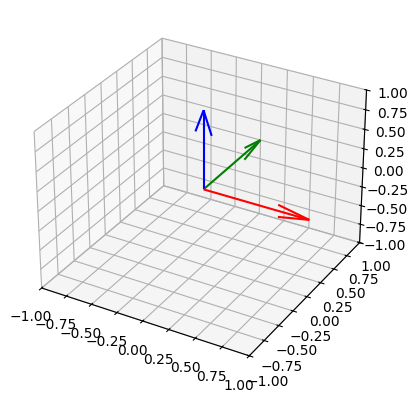

In [ ]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')

def update(frame):

    ax.clear()

    R = R_history[frame]

    b1 = R[:,0]
    b2 = R[:,1]
    b3 = R[:,2]

    ax.quiver(0,0,0,*b1,color='r')
    ax.quiver(0,0,0,*b2,color='g')
    ax.quiver(0,0,0,*b3,color='b')

    ax.set_xlim([-1,1])
    ax.set_ylim([-1,1])
    ax.set_zlim([-1,1])

ani = FuncAnimation(fig, update, frames=len(R_history), interval=40)